In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("income.csv")
print(df.head())

   age     sex    education  education-num marital-status    workclass  \
0   27    Male      HS-grad              9  Never-married      Private   
1   47    Male      Masters             14        Married    Local-gov   
2   59    Male      HS-grad              9       Divorced     Self-emp   
3   38  Female  Prof-school             15  Never-married  Federal-gov   
4   64  Female         11th              7        Widowed      Private   

        occupation  hours-per-week income  label  
0     Craft-repair              40  <=50K      0  
1  Exec-managerial              50   >50K      1  
2   Prof-specialty              20  <=50K      0  
3   Prof-specialty              57   >50K      1  
4  Farming-fishing              40  <=50K      0  


In [5]:
print(df.columns)

Index(['age', 'sex', 'education', 'education-num', 'marital-status',
       'workclass', 'occupation', 'hours-per-week', 'income', 'label'],
      dtype='object')


In [6]:
df.columns = df.columns.str.strip()

In [7]:
categorical_cols = [
    'sex',
    'education',
    'marital-status',
    'workclass',
    'occupation'
]
continuous_cols = [
    'age',
    'education-num',
    'hours-per-week'
]
label_col = 'income'

In [8]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [9]:
df[label_col] = df[label_col].apply(lambda x: 1 if '>50K' in x else 0)

In [10]:
cat_data = np.stack([df[col].values for col in categorical_cols], axis=1)
cont_data = np.stack([df[col].values for col in continuous_cols], axis=1)
labels = df[label_col].values

cat_tensor = torch.tensor(cat_data, dtype=torch.long)
cont_tensor = torch.tensor(cont_data, dtype=torch.float)
label_tensor = torch.tensor(labels, dtype=torch.long)

In [11]:
train_size = 25000

cat_train = cat_tensor[:train_size]
cat_test = cat_tensor[train_size:]

cont_train = cont_tensor[:train_size]
cont_test = cont_tensor[train_size:]

y_train = label_tensor[:train_size]
y_test = label_tensor[train_size:]

In [12]:
class TabularModel(nn.Module):
    def __init__(self, emb_sizes, n_cont):
        super().__init__()

        # Embedding layers
        self.embeds = nn.ModuleList([
            nn.Embedding(categories, size)
            for categories, size in emb_sizes
        ])

        self.emb_dropout = nn.Dropout(0.4)
        # Batch norm for continuous
        self.bn_cont = nn.BatchNorm1d(n_cont)
        # Fully connected layers
        n_emb = sum(e.embedding_dim for e in self.embeds)
        self.fc1 = nn.Linear(n_emb + n_cont, 50)
        self.fc2 = nn.Linear(50, 2)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x_cat, x_cont):
        embeddings = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeds)]
        x = torch.cat(embeddings, dim=1)
        x = self.emb_dropout(x)
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], dim=1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [13]:
class TabularModel(nn.Module):
    def __init__(self, emb_sizes, n_cont):
        super().__init__()

        # Embedding layers
        self.embeds = nn.ModuleList([
            nn.Embedding(categories, size)
            for categories, size in emb_sizes
        ])

        self.emb_dropout = nn.Dropout(0.4)
        # Batch norm for continuous
        self.bn_cont = nn.BatchNorm1d(n_cont)
        # Fully connected layers
        n_emb = sum(e.embedding_dim for e in self.embeds)
        self.fc1 = nn.Linear(n_emb + n_cont, 50)
        self.fc2 = nn.Linear(50, 2)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x_cat, x_cont):
        embeddings = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeds)]
        x = torch.cat(embeddings, dim=1)
        x = self.emb_dropout(x)
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], dim=1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [14]:
emb_sizes = [(len(df[col].unique()), min(50, (len(df[col].unique())+1)//2)) for col in categorical_cols]

In [15]:
torch.manual_seed(42)
model = TabularModel(emb_sizes, cont_data.shape[1])

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 300

for i in range(epochs):
    model.train()

    y_pred = model(cat_train, cont_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 25 == 0:
        print(f"Epoch {i}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.6802
Epoch 25, Loss: 0.5225
Epoch 50, Loss: 0.4537
Epoch 75, Loss: 0.4060
Epoch 100, Loss: 0.3768
Epoch 125, Loss: 0.3605
Epoch 150, Loss: 0.3451
Epoch 175, Loss: 0.3353
Epoch 200, Loss: 0.3294
Epoch 225, Loss: 0.3214
Epoch 250, Loss: 0.3160
Epoch 275, Loss: 0.3083


In [17]:
model.eval()

with torch.no_grad():
    preds = model(cat_test, cont_test)
    loss = criterion(preds, y_test)

    predicted = torch.argmax(preds, dim=1)
    accuracy = (predicted == y_test).sum().item() / len(y_test)

print(f"Test Loss: {loss.item():.4f}")
print(f"Accuracy: {accuracy:.4f}")

Test Loss: 0.2765
Accuracy: 0.8752


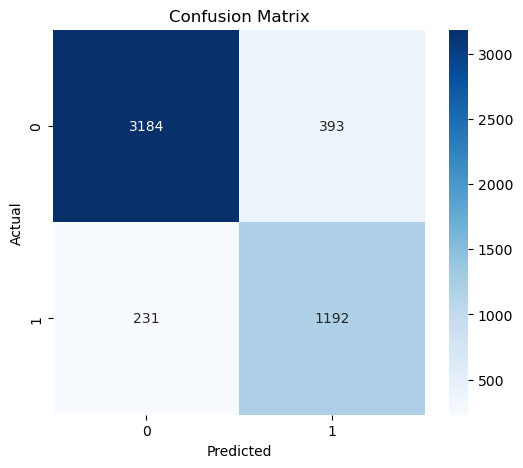

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predicted)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()